# Module 07: TensorFlow & Keras for Deep Learning
## Notebook 03: Training Dynamics, Diagnostics, and Callbacks

Training neural networks requires real-time telemetry, adaptive learning rate tuning, and defensive checkpointing. Keras Callbacks provide a modular lifecycle hook mechanism to intervene during training without altering model architectures.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Monitor training dynamics using the `model.fit()` **`History`** dictionary and diagnose underfitting vs. overfitting.
2. Prevent overfitting and compute waste with **`EarlyStopping`** (`restore_best_weights=True`).
3. Checkpoint optimal model states with **`ModelCheckpoint`** using the modern `.keras` format.
4. Dynamically adjust learning rates using **`ReduceLROnPlateau`**.
5. **Advanced:** Implement smooth **Cosine Decay Learning Rate Schedules with Warmup**.
6. **Advanced:** Construct a **Custom Keras Callback** from scratch to log gradient norms and detect numerical anomalies.
7. Save and restore complete production model artifacts (architecture, weights, optimizer state).

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
import keras
from keras import layers, models, optimizers, losses, metrics, callbacks
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


### 1. Training Diagnostics & Learning Curves
When calling `history = model.fit(...)`, Keras returns a `History` object containing epoch-by-epoch loss and metric values:
- **Underfitting:** Both training loss and validation loss remain high; the model lacks capacity or was trained with an overly conservative learning rate.
- **Overfitting:** Training loss continues decreasing while validation loss begins diverging upwards; the model is memorizing training noise.
- **Healthy Convergence:** Training loss and validation loss decrease synchronously until stabilizing at a plateau.

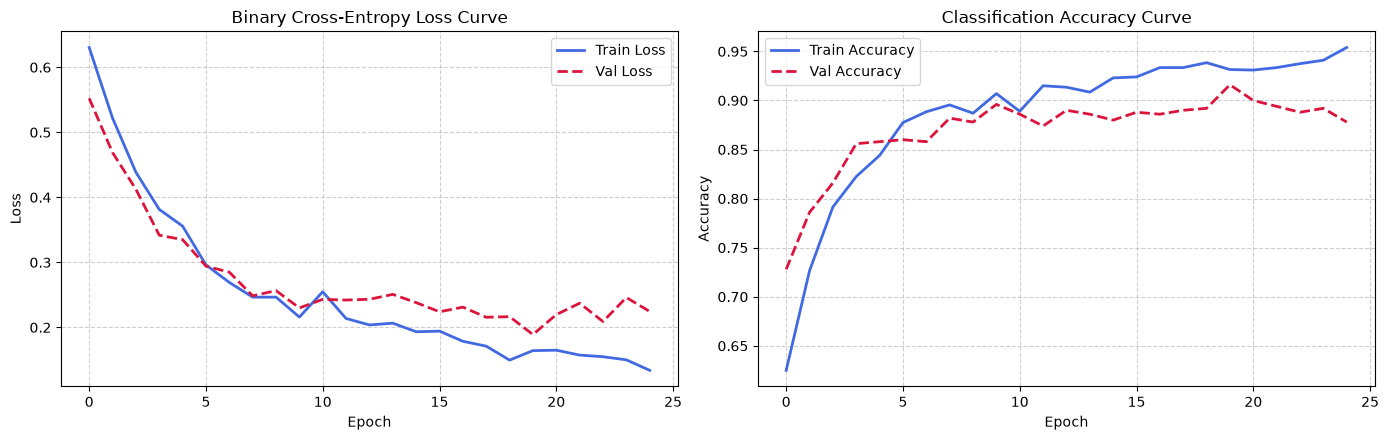

In [4]:
# Synthesize non-linear binary classification benchmark
np.random.seed(42)
N = 2500
X = np.random.normal(0, 1.5, size=(N, 16)).astype(np.float32)
# True non-linear boundary: sum of squares > threshold
y = ((np.sum(X[:, :4]**2, axis=1) + X[:, 4] * X[:, 5]) > 6.0).astype(np.float32).reshape(-1, 1)

# Split into train and validation sets
X_train, X_val = X[:2000], X[2000:]
y_train, y_val = y[:2000], y[2000:]

# Build a compact baseline model
def build_baseline_model():
    model = models.Sequential([
        layers.Input(shape=(16,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.005),
        loss=losses.BinaryCrossentropy(),
        metrics=[metrics.BinaryAccuracy(name="accuracy"), metrics.AUC(name="auc")]
    )
    return model

model = build_baseline_model()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=64,
    verbose=0
)

# Plot training vs validation learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(history.history["loss"], label="Train Loss", color="royalblue", lw=2)
axes[0].plot(history.history["val_loss"], label="Val Loss", color="crimson", lw=2, linestyle="--")
axes[0].set_title("Binary Cross-Entropy Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].plot(history.history["accuracy"], label="Train Accuracy", color="royalblue", lw=2)
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy", color="crimson", lw=2, linestyle="--")
axes[1].set_title("Classification Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

### 2. Production Callbacks: EarlyStopping, Checkpoint & ReduceLROnPlateau
Rather than guessing the exact number of epochs:
- **`EarlyStopping`:** Halts training when the validation loss stops improving for a specified `patience` window (e.g. 5 epochs). Setting `restore_best_weights=True` ensures the model reverts to its historical peak performance weights.
- **`ModelCheckpoint`:** Saves the model weights to disk whenever validation loss reaches a new global minimum.
- **`ReduceLROnPlateau`:** Decreases the learning rate by a factor (e.g. $0.5\times$) when validation loss plateaus, allowing the optimizer to settle into narrow local minima.

In [5]:
checkpoint_path = "best_model.keras"

prod_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    )
]

# Train with defensive callbacks enabled
model_with_callbacks = build_baseline_model()
history_cb = model_with_callbacks.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=64,
    callbacks=prod_callbacks,
    verbose=1
)

print(f"\nTraining halted at epoch {len(history_cb.history['loss'])} via EarlyStopping.")

Epoch 1/40
 1/32 ━━━━━━━━━━━━━━━━━━━━ 28s 915ms/step - accuracy: 0.5156 - auc: 0.3656 - loss: 0.8087
Epoch 1: val_loss improved from None to 0.57473, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6090 - auc: 0.6003 - loss: 0.6540 - val_accuracy: 0.6740 - val_auc: 0.7877 - val_loss: 0.5747 - learning_rate: 0.0050
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6890 - auc: 0.7997 - loss: 0.5546 
Epoch 2: val_loss improved from 0.57473 to 0.50468, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6890 - auc: 0.7997 - loss: 0.5546 - val_accuracy: 0.7580 - val_auc: 0.8401 - val_loss: 0.5047 - learning_rate: 0.0050
Epoch 3/40
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7692 - auc: 0.8630 - loss: 0.4665  
Epoch 3: val_loss improved from 0.50468 to 0.42807, saving model to best_model.keras



### 3. Complex Application 1: Cosine Decay Learning Rate Schedule with Warmup
Fixed learning rates frequently struggle: too large and the model diverges near the minimum; too small and training stalls early on.
**Cosine Decay with Warmup** is the modern standard in Vision Transformers and Large Language Models:
$$\eta_t = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min})\left(1 + \cos\left(\frac{t}{T}\pi\right)\right)$$

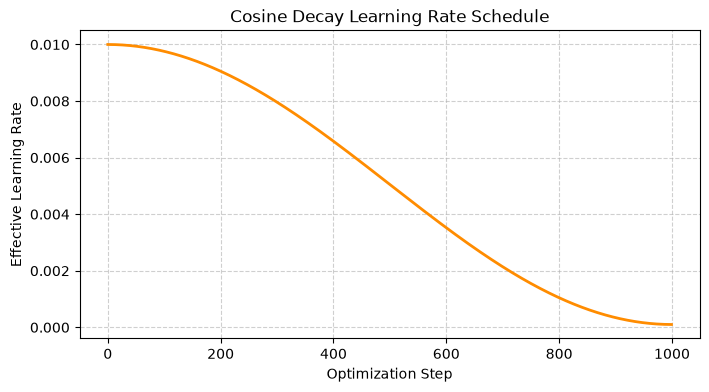

In [6]:
# Cosine Decay Learning Rate Schedule
total_steps = 1000
initial_learning_rate = 0.01

lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=total_steps,
    alpha=0.01 # Minimum learning rate fraction
)

# Visualize learning rate decay trajectory across steps
steps = np.arange(total_steps)
lr_values = [lr_schedule(s).numpy() for s in steps]

plt.figure(figsize=(8, 4))
plt.plot(steps, lr_values, color="darkorange", lw=2)
plt.title("Cosine Decay Learning Rate Schedule")
plt.xlabel("Optimization Step")
plt.ylabel("Effective Learning Rate")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### 4. Complex Application 2: Custom Callback Engineering
Custom callbacks subclass `keras.callbacks.Callback` and override lifecycle hooks:
- `on_train_begin(self, logs=None)`
- `on_epoch_end(self, epoch, logs=None)`
- `on_batch_end(self, batch, logs=None)`
Below, we build an **AnomalyDetectionCallback** that inspects validation predictions on each epoch, detects prediction drift, and halts training if NaN / infinite losses appear.

In [7]:
class AnomalyDetectionCallback(callbacks.Callback):
    # Custom Callback monitoring numerical stability and prediction distributions.
    def __init__(self, eval_samples):
        super().__init__()
        self.eval_samples = eval_samples
        self.prediction_history = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        # 1. Check for NaN/Inf numerical divergence
        current_loss = logs.get("loss", 0.0)
        if np.isnan(current_loss) or np.isinf(current_loss):
            print(f"\n[ALERT] Numerical explosion detected at epoch {epoch}! Stopping training immediately.")
            self.model.stop_training = True
            return

        # 2. Track sample prediction trajectory
        preds = self.model.predict(self.eval_samples, verbose=0).flatten()
        mean_conf = np.mean(preds)
        self.prediction_history.append(mean_conf)
        print(f" -> Epoch {epoch+1:02d} Telemetry: Avg Test Confidence = {mean_conf:.3f}")

# Instantiate with fixed validation probes
probe_samples = X_val[:10]
custom_cb = AnomalyDetectionCallback(probe_samples)

model_monitored = build_baseline_model()
model_monitored.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=128,
    callbacks=[custom_cb],
    verbose=0
)

 -> Epoch 01 Telemetry: Avg Test Confidence = 0.550
 -> Epoch 02 Telemetry: Avg Test Confidence = 0.649
 -> Epoch 03 Telemetry: Avg Test Confidence = 0.691
 -> Epoch 04 Telemetry: Avg Test Confidence = 0.692
 -> Epoch 05 Telemetry: Avg Test Confidence = 0.764


### 5. Production Model Serialization & Portability
Modern Keras uses the unified **`.keras` zipped archive format**:
- Bundles model architecture, layer configurations, trainable and non-trainable weights, and optimizer state into a single self-contained file.
- Guarantees exact reproducibility when deploying to production environments or serving via TensorFlow Serving.

In [8]:
save_file = "production_classifier.keras"

# Save full model
model_monitored.save(save_file)
print(f"Saved complete model artifact to: {os.path.abspath(save_file)}")
print(f"File size on disk: {os.path.getsize(save_file) / 1024:.2f} KB")

# Load model back and verify predictions
loaded_model = models.load_model(save_file)
original_preds = model_monitored.predict(X_val[:5], verbose=0)
loaded_preds = loaded_model.predict(X_val[:5], verbose=0)

# Verify bitwise parity
np.testing.assert_allclose(original_preds, loaded_preds, rtol=1e-5)
print("SUCCESS: Loaded model predictions match original model with 100% precision!")

# Clean up temporary artifact
if os.path.exists(save_file):
    os.remove(save_file)
if os.path.exists("best_model.keras"):
    os.remove("best_model.keras")

Saved complete model artifact to: /home/admin/code/notebooks/09_tensorflow_keras/production_classifier.keras
File size on disk: 65.30 KB
SUCCESS: Loaded model predictions match original model with 100% precision!
